In [9]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np
import random
import matplotlib.pyplot as plt

#spark session
spark = SparkSession.builder.appName("Spark SQL Homework - Realistic Stable").getOrCreate()
spark.sparkContext.setLogLevel("WARN")

random.seed(42)
np.random.seed(42)

#dimensi
departments = [(1,"HR"),(2,"Marketing"),(3,"Engineering"),(4,"Finance"),(5,"Sales"),(6,"Support")]
projects    = [(1,"Project A"),(2,"Project B"),(3,"Project C"),(4,"Project D"),(5,"Project E"),(6,"Project F")]
base_salary = {1:3200, 2:4000, 3:5200, 4:4700, 5:3900, 6:3600}

#data nama
male_names = ["Rizky","Bayu","Ardi","Dimas","Fajar","Rafi","Bagus","Taufik","Bima","Doni",
              "Eko","Fahri","Gilang","Hendra","Iqbal","Joko","Kevin","Lukman","Miko","Niko",
              "Omar","Putra","Reno","Seno","Teguh","Umar","Vito","Wibi","Yoga","Zaki",
              "Andra","Budi","Chandra","Dian","Evan","Fikri","Gio","Hafiz","Ilham","Johan",
              "Krisna","Lutfi","Mahendra","Naufal","Oka","Rama","Syahrul","Tono","Yusuf","Zain",
              "Arman","Denny","Fauzan","Haris","Imam","Jefri","Kurniawan","Rizal","Satria","Yudi"]

female_names = ["Ayu","Bella","Citra","Dewi","Erna","Fitri","Gina","Hana","Intan","Jihan",
                "Kartika","Lia","Maya","Nadya","Olivia","Putri","Qori","Rani","Sinta","Tika",
                "Uli","Vina","Wulan","Xenia","Yani","Zahra","Anisa","Bianca","Clara","Desi",
                "Elly","Fira","Gita","Hesti","Indah","Jeni","Kania","Lina","Mila","Novi",
                "Olia","Poppy","Rosa","Sari","Tania","Vivi","Winda","Yola","Zora","Amanda",
                "Cindy","Dinda","Eka","Farah","Gracia","Ines","Joana","Laras","Melati","Naila"]

all_names = male_names + female_names
random.shuffle(all_names) 

dept_distribution = {
    1: 12,  # HR
    2: 18,  # Marketing
    3: 30,  # Engineering
    4: 24,  # Finance
    5: 18,  # Sales
    6: 18   # Support
}

#bangun data: nama, usia, gender, salary, dept
rows, name_idx = [], 0
for dept, count in dept_distribution.items():
    for _ in range(count):
        name   = all_names[name_idx % len(all_names)]
        age    = random.randint(22, 55)
        gender = "M" if name in male_names else "F"
        base   = base_salary[dept]
        # gaji realistis sekitar base, dibatasi agar tetap masuk akal
        salary = int(np.clip(np.random.normal(base, 450), 2500, 7000))
        rows.append((name, age, gender, salary, dept))
        name_idx += 1

employees   = spark.createDataFrame(rows, ["Name","Age","Gender","Salary","DeptId"])
departments = spark.createDataFrame(departments, ["DeptId","DeptName"])
projects    = spark.createDataFrame(projects,    ["DeptId","ProjectName"])

employees.createOrReplaceTempView("employees")
departments.createOrReplaceTempView("departments")
projects.createOrReplaceTempView("projects")

print("Total rows:", employees.count())
employees.show(15, truncate=False)

Total rows: 120
+-------+---+------+------+------+
|Name   |Age|Gender|Salary|DeptId|
+-------+---+------+------+------+
|Doni   |30 |M     |3423  |1     |
|Yani   |54 |F     |3137  |1     |
|Jeni   |53 |F     |3491  |1     |
|Gracia |27 |F     |3885  |1     |
|Gita   |25 |F     |3094  |1     |
|Andra  |29 |M     |3094  |1     |
|Hesti  |31 |F     |3910  |1     |
|Bianca |32 |F     |3545  |1     |
|Kania  |49 |F     |2988  |1     |
|Amanda |26 |F     |3444  |1     |
|Tono   |46 |M     |2991  |1     |
|Tika   |46 |F     |2990  |1     |
|Clara  |51 |F     |4108  |2     |
|Chandra|55 |M     |3139  |2     |
|Kevin  |38 |M     |3223  |2     |
+-------+---+------+------+------+
only showing top 15 rows



+-----------+-----------+--------+
|   DeptName|TotalSalary|EmpCount|
+-----------+-----------+--------+
|Engineering|     154349|      30|
|    Finance|     113000|      24|
|         HR|      39992|      12|
|  Marketing|      67853|      18|
|      Sales|      68656|      18|
|    Support|      66015|      18|
+-----------+-----------+--------+



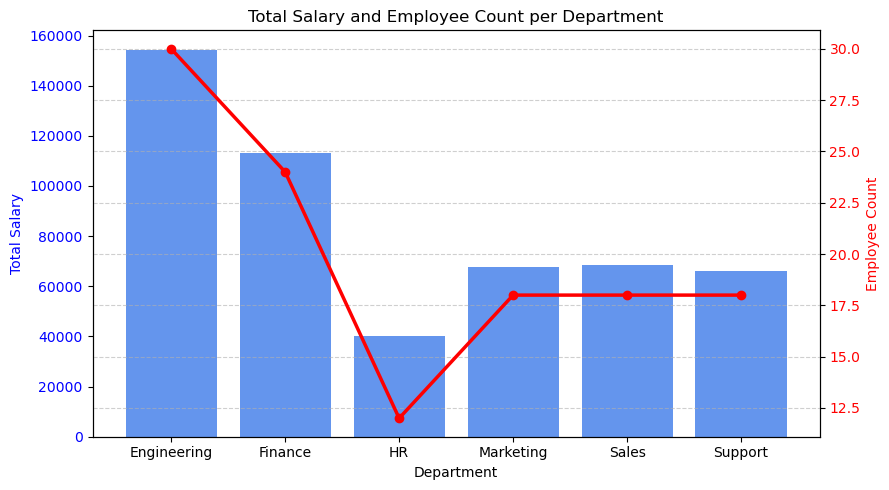

In [14]:
#SQL agregasi: SUM (total gaji) + COUNT (jumlah karyawan) per departemen
agg_dept = spark.sql("""
SELECT  d.DeptName,
        SUM(e.Salary)  AS TotalSalary,
        COUNT(*)       AS EmpCount
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
ORDER BY d.DeptName
""")

agg_dept.show()
pdf_agg = agg_dept.toPandas()
pdf_agg

#visualisasi perbandingan antar departemen (dual-axis)
fig, ax1 = plt.subplots(figsize=(9,5))

#batang totalsalary
ax1.bar(pdf_agg["DeptName"], pdf_agg["TotalSalary"],
        color="cornflowerblue", label="Total Salary")
ax1.set_xlabel("Department")
ax1.set_ylabel("Total Salary", color="blue")
ax1.tick_params(axis='y', labelcolor='blue')

#garis employee count di sumbu kanan
ax2 = ax1.twinx()
ax2.plot(pdf_agg["DeptName"], pdf_agg["EmpCount"],
         color="red", marker="o", linewidth=2.5, label="Employee Count")
ax2.set_ylabel("Employee Count", color="red")
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Total Salary and Employee Count per Department")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()

+---------+---+--------+------+-----------------+
|Name     |Age|AgeGroup|Salary|AvgByGroup       |
+---------+---+--------+------+-----------------+
|Miko     |32 |30s     |5663  |4382.675675675676|
|Sari     |34 |30s     |5638  |4382.675675675676|
|Zain     |38 |30s     |5619  |4382.675675675676|
|Gilang   |36 |30s     |5404  |4382.675675675676|
|Ardi     |35 |30s     |5349  |4382.675675675676|
|Lutfi    |34 |30s     |5193  |4382.675675675676|
|Joko     |37 |30s     |5151  |4382.675675675676|
|Bagus    |30 |30s     |5026  |4382.675675675676|
|Seno     |37 |30s     |4992  |4382.675675675676|
|Kurniawan|30 |30s     |4895  |4382.675675675676|
|Satria   |36 |30s     |4862  |4382.675675675676|
|Arman    |31 |30s     |4724  |4382.675675675676|
|Yoga     |39 |30s     |4708  |4382.675675675676|
|Rama     |36 |30s     |4683  |4382.675675675676|
|Johan    |32 |30s     |4650  |4382.675675675676|
|Naila    |36 |30s     |4565  |4382.675675675676|
|Dewi     |37 |30s     |4534  |4382.675675675676|


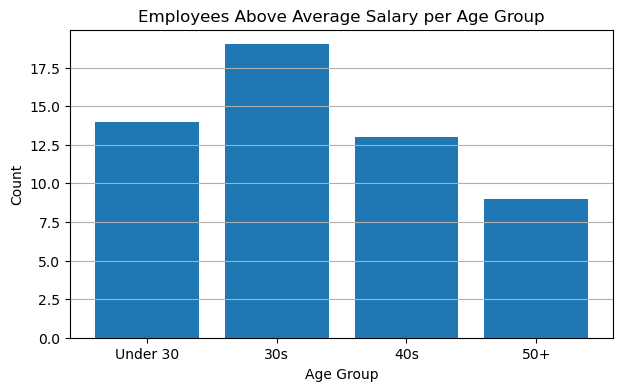

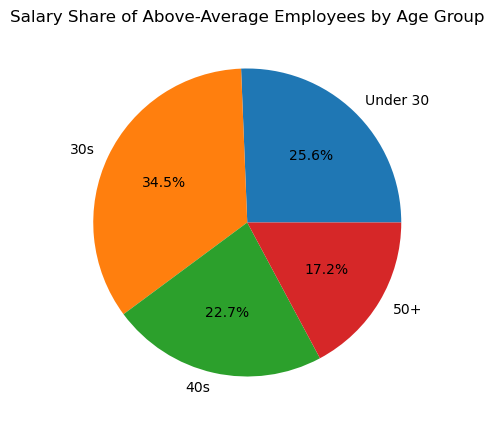

In [11]:
#kelompok usia
emp_age = employees.withColumn(
    "AgeGroup",
    F.when(F.col("Age") < 30, "Under 30")
     .when((F.col("Age") >= 30) & (F.col("Age") < 40), "30s")
     .when((F.col("Age") >= 40) & (F.col("Age") < 50), "40s")
     .otherwise("50+")
)
emp_age.createOrReplaceTempView("employees_age")

#karyawan dengan salary > rata-rata kelompok usia (window)
above_avg = spark.sql("""
SELECT Name, Age, AgeGroup, Salary,
       AVG(Salary) OVER (PARTITION BY AgeGroup) AS AvgByGroup
FROM employees_age
""").filter("Salary > AvgByGroup") \
  .orderBy("AgeGroup","Salary", ascending=[True, False])

#tabel hasil 
above_avg.show(30, truncate=False)
pdf_above = above_avg.toPandas()
pdf_above.head()

#grafik batang: jumlah karyawan "above average" per AgeGroup
counts = (pdf_above.groupby("AgeGroup")["Name"]
          .count()
          .reindex(["Under 30","30s","40s","50+"])
          .fillna(0))

plt.figure(figsize=(7,4))
plt.bar(counts.index, counts.values)
plt.title("Employees Above Average Salary per Age Group")
plt.xlabel("Age Group"); plt.ylabel("Count")
plt.grid(True, axis="y")
plt.show()

#pie chart: proporsi total salary dari yang "above average" per AgeGroup
sum_by_group = (pdf_above.groupby("AgeGroup")["Salary"]
                .sum()
                .reindex(["Under 30","30s","40s","50+"])
                .fillna(0))

plt.figure(figsize=(5,5))
plt.pie(sum_by_group.values, labels=sum_by_group.index, autopct="%1.1f%%")
plt.title("Salary Share of Above-Average Employees by Age Group")
plt.show()

In [12]:
agg_full = spark.sql("""
SELECT
  d.DeptName,
  COUNT(*)                             AS EmpCount,          -- COUNT()
  ROUND(AVG(e.Salary), 2)              AS AvgSalary,         -- AVG()
  SUM(e.Salary)                        AS TotalSalary,       -- SUM()
  MIN(e.Salary)                        AS MinSalary,
  MAX(e.Salary)                        AS MaxSalary,
  ROUND(STDDEV(e.Salary), 2)           AS StdDevSalary,
  PERCENTILE_APPROX(e.Salary, 0.5)     AS MedianSalary       -- median approx
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId                     -- JOIN
GROUP BY d.DeptName
ORDER BY d.DeptName
""")

agg_full.show(truncate=False)
pdf_full = agg_full.toPandas()
pdf_full

proj_map = spark.sql("""
SELECT
  p.ProjectName,
  d.DeptName,
  COUNT(*) AS EmpCount
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects    p ON e.DeptId = p.DeptId
GROUP BY p.ProjectName, d.DeptName
ORDER BY p.ProjectName
""")

proj_map.show(truncate=False)

top3 = spark.sql("""
SELECT DeptName, Name, Salary, RankInDept
FROM (
  SELECT
    d.DeptName,
    e.Name,
    e.Salary,
    ROW_NUMBER() OVER (PARTITION BY d.DeptName ORDER BY e.Salary DESC) AS RankInDept
  FROM employees e
  JOIN departments d ON e.DeptId = d.DeptId
) t
WHERE RankInDept <= 3
ORDER BY DeptName, RankInDept
""")

top3.show(50, truncate=False)



+-----------+--------+---------+-----------+---------+---------+------------+------------+
|DeptName   |EmpCount|AvgSalary|TotalSalary|MinSalary|MaxSalary|StdDevSalary|MedianSalary|
+-----------+--------+---------+-----------+---------+---------+------------+------------+
|Engineering|30      |5144.97  |154349     |4318     |6033     |418.94      |5147        |
|Finance    |24      |4708.33  |113000     |3521     |5404     |479.74      |4683        |
|HR         |12      |3332.67  |39992      |2988     |3910     |334.97      |3137        |
|Marketing  |18      |3769.61  |67853      |3139     |4659     |389.07      |3746        |
|Sales      |18      |3814.22  |68656      |3241     |4335     |308.18      |3752        |
|Support    |18      |3667.5   |66015      |2736     |4708     |454.19      |3588        |
+-----------+--------+---------+-----------+---------+---------+------------+------------+



+-----------+-----------+--------+
|ProjectName|DeptName   |EmpCount|
+-----------+-----------+--------+
|Project A  |HR         |12      |
|Project B  |Marketing  |18      |
|Project C  |Engineering|30      |
|Project D  |Finance    |24      |
|Project E  |Sales      |18      |
|Project F  |Support    |18      |
+-----------+-----------+--------+



[Stage 144:===============================================>         (5 + 1) / 6]

+-----------+-------+------+----------+
|DeptName   |Name   |Salary|RankInDept|
+-----------+-------+------+----------+
|Engineering|Fauzan |6033  |1         |
|Engineering|Krisna |5675  |2         |
|Engineering|Miko   |5663  |3         |
|Finance    |Gilang |5404  |1         |
|Finance    |Oka    |5392  |2         |
|Finance    |Tania  |5365  |3         |
|HR         |Hesti  |3910  |1         |
|HR         |Gracia |3885  |2         |
|HR         |Bianca |3545  |3         |
|Marketing  |Bima   |4659  |1         |
|Marketing  |Kartika|4169  |2         |
|Marketing  |Lina   |4141  |3         |
|Sales      |Desi   |4335  |1         |
|Sales      |Vivi   |4311  |2         |
|Sales      |Haris  |4130  |3         |
|Support    |Yoga   |4708  |1         |
|Support    |Fahri  |4448  |2         |
|Support    |Iqbal  |4114  |3         |
+-----------+-------+------+----------+



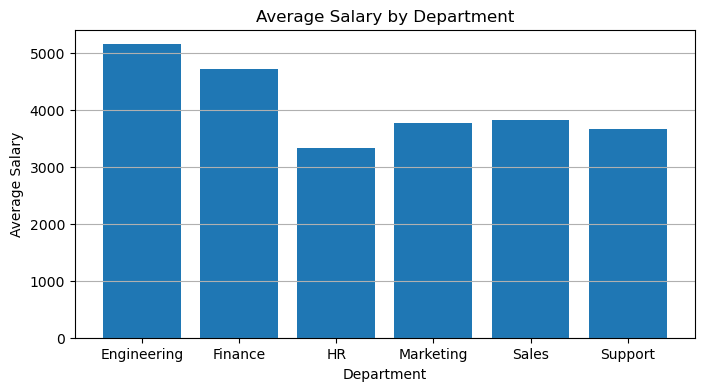

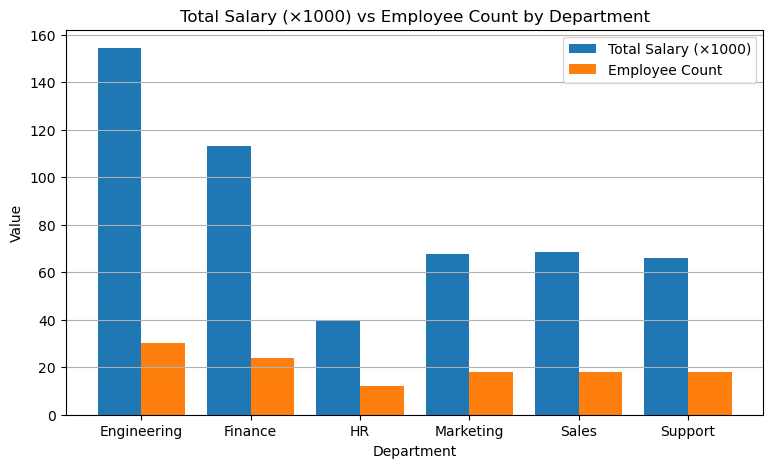

/tmp/ipykernel_3056/3845110439.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(salary_detail["DeptName"].unique()))


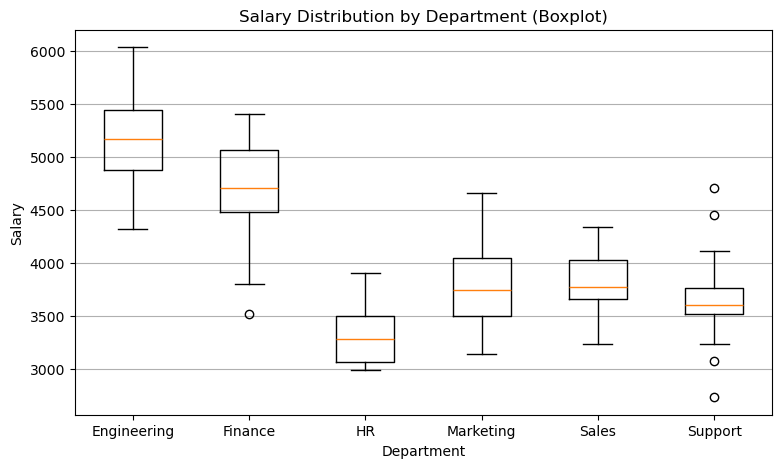

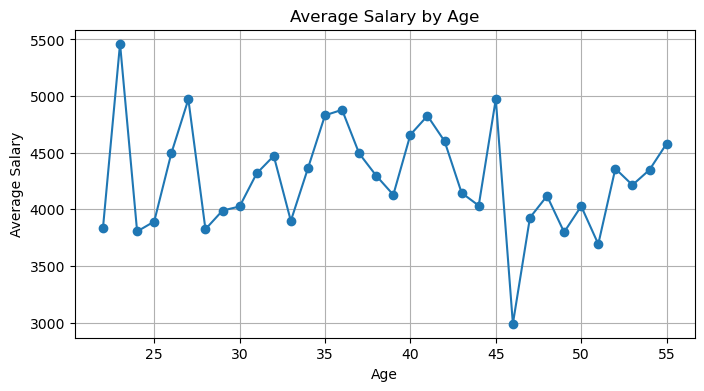

+-----------+--------+---------+-----------+
|   DeptName|EmpCount|AvgSalary|TotalSalary|
+-----------+--------+---------+-----------+
|Engineering|      30|  5144.97|     154349|
|    Finance|      24|  4708.33|     113000|
|         HR|      12|  3332.67|      39992|
|  Marketing|      18|  3769.61|      67853|
|      Sales|      18|  3814.22|      68656|
|    Support|      18|   3667.5|      66015|
+-----------+--------+---------+-----------+



In [13]:
#visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(pdf_full["DeptName"], pdf_full["AvgSalary"])
plt.title("Average Salary by Department")
plt.xlabel("Department"); plt.ylabel("Average Salary")
plt.grid(True, axis="y")
plt.show()

import numpy as np

x = np.arange(len(pdf_full["DeptName"]))
w = 0.4

plt.figure(figsize=(9,5))
plt.bar(x - w/2, (pdf_full["TotalSalary"]/1000).values, width=w, label="Total Salary (×1000)")
plt.bar(x + w/2, pdf_full["EmpCount"].values,          width=w, label="Employee Count")
plt.xticks(x, pdf_full["DeptName"])
plt.xlabel("Department"); plt.ylabel("Value")
plt.title("Total Salary (×1000) vs Employee Count by Department")
plt.legend(); plt.grid(True, axis="y")
plt.show()

#ambil data detail gaji per departemen dari Spark → Pandas
salary_detail = spark.sql("""
SELECT d.DeptName, e.Salary
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
""").toPandas()

#susun data untuk boxplot
groups = [g["Salary"].values for _, g in salary_detail.groupby("DeptName")]

plt.figure(figsize=(9,5))
plt.boxplot(groups, labels=sorted(salary_detail["DeptName"].unique()))
plt.title("Salary Distribution by Department (Boxplot)")
plt.xlabel("Department"); plt.ylabel("Salary")
plt.grid(True, axis="y")
plt.show()

trend_age = spark.sql("""
SELECT Age, ROUND(AVG(Salary),2) AS AvgSalaryByAge
FROM employees
GROUP BY Age
ORDER BY Age
""").toPandas()

plt.figure(figsize=(8,4))
plt.plot(trend_age["Age"], trend_age["AvgSalaryByAge"], marker="o")
plt.title("Average Salary by Age")
plt.xlabel("Age"); plt.ylabel("Average Salary")
plt.grid(True)
plt.show()

agg_core = spark.sql("""
SELECT d.DeptName,
       COUNT(*)               AS EmpCount,
       ROUND(AVG(e.Salary),2) AS AvgSalary,
       SUM(e.Salary)          AS TotalSalary
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
ORDER BY d.DeptName
""")
agg_core.show()